In [ ]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from pathlib import Path
import numpy as np

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.5)

REPO_ROOT = Path.cwd()
DATA_DIR = Path(os.environ.get("GUESS_WHO_DATA_DIR", REPO_ROOT / "experiments" / "guess_who" / "data"))
EXPERIMENTS_DIR = Path(os.environ.get("GUESS_WHO_EXPERIMENTS_DIR", DATA_DIR / "experiments"))
POSTHOC_CSV = Path(os.environ.get("GUESS_WHO_POSTHOC_CSV", DATA_DIR / "posthoc_eig_results.csv"))
EXPORT_DIR = Path(os.environ.get("GUESS_WHO_EXPORT_DIR", REPO_ROOT / "experiments" / "guess_who"))
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def load_experiment_data(experiments_dir):
    """Load all game data from JSON files"""
    # Load individual game files
    game_files = glob(os.path.join(experiments_dir, "game_*.json"))
    
    # Load summary files for additional context
    summary_files = glob(os.path.join(experiments_dir, "experiment_summary_*.json"))
    
    games_data = []
    
    # Load individual game results
    for file_path in game_files:
        try:
            with open(file_path, 'r') as f:
                game_data = json.load(f)
                if 'error' not in game_data:  # Only include successful games
                    games_data.append(game_data)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    # Load summary files for additional context
    summary_data = []
    for file_path in summary_files:
        try:
            with open(file_path, 'r') as f:
                summary = json.load(f)
                summary_data.append(summary)
        except Exception as e:
            print(f"Error loading summary {file_path}: {e}")
    
    return games_data, summary_data

def analyze_game_outcomes(games_data):
    """Analyze game outcomes and determine if player won"""
    results = []
    
    for game in games_data:
        # Determine if player won based on rewards
        player_won = False
        if 'rewards' in game and game['rewards']:
            # In 20 Questions, player wins if they get positive reward (successful guess)
            player_reward = game['rewards']["0"]  # Player 0's reward
            player_won = player_reward > 0
        
        # Extract final guess if available
        final_guess = None
        if 'observations' in game:
            for obs in reversed(game['observations']):
                if obs['player'] == 0 and '[' in obs['message'] and ']' in obs['message']:
                    final_guess = obs['message']
                    break
        
        result = {
            'game_id': game.get('game_id'),
            'model_name': game.get('model_name'),
            'agent_type': game.get('agent_type'),
            'player_won': player_won,
            'turn_count': game.get('turn_count', 0),
            'game_duration': game.get('game_duration', 0),
            'ground_truth_word': game.get('ground_truth_word'),
            'ground_truth_theme': game.get('ground_truth_theme'),
            'final_guess': final_guess,
            'timestamp': game.get('timestamp')
        }
        results.append(result)
    
    return pd.DataFrame(results)

# Load the data
print(f"Loading experiment data from {EXPERIMENTS_DIR}...")
games_data, summary_data = load_experiment_data(EXPERIMENTS_DIR)

print(f"Loaded {len(games_data)} games and {len(summary_data)} summaries")

if games_data:
    # Convert to DataFrame for analysis
    df = analyze_game_outcomes(games_data)
    print(f"Analyzed {len(df)} games successfully")
    
    # Show basic info
    print(f"\nModels tested: {df['model_name'].unique()}")
    print(f"Agent types tested: {df['agent_type'].unique()}")
    print(f"Overall win rate: {df['player_won'].mean():.1%}")
else:
    print("No game data found. Make sure to run experiments first!")

Loading experiment data...
Loaded 477 games and 3 summaries
Analyzed 477 games successfully

Models tested: ['meta-llama/llama-4-scout' 'openai/gpt-4o']
Agent types tested: ['QBayes' 'MBayes' 'LLM' 'EIG']
Overall win rate: 61.6%


In [6]:
df.loc[df['agent_type'] == 'EIG', 'agent_type'] = 'QMBayes'
df.loc[df['model_name'] == 'meta-llama/llama-4-scout', 'model_name'] = 'Llama-4-Scout'
df.loc[df['model_name'] == 'openai/gpt-4o', 'model_name'] = 'GPT-4o'
df.loc[df['model_name'] == 'openai/gpt-5', 'model_name'] = 'GPT-5'

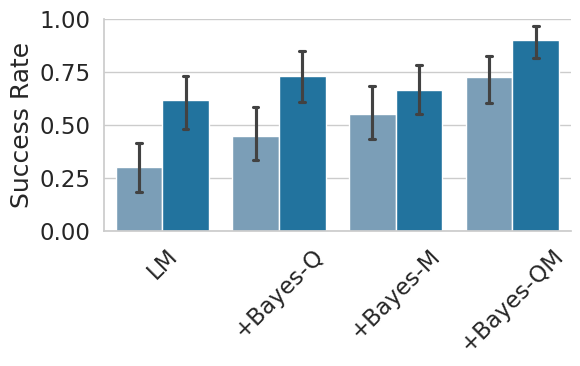

In [ ]:
# Update the agent_type labels
df['agent_type'] = df['agent_type'].replace({
    'LLM': 'LM',
    'QBayes': '+Bayes-Q',
    'MBayes': '+Bayes-M',
    'QMBayes': '+Bayes-QM'
})

# Rename the y-axis to Success Rate and change to 0-100%
# Set legend=None and remove the title and x-axis label
# New colors:
colors = {
    "Sea green": "#008f69",
    "Battleship gray": "#848482",
    "Cadet gray": "#91a3b0",
    "Air superiority blue": "#71a0c1",
    "Honolulu Blue": "#0e79b2",
    "Navy blue": "#000080",
}

llm_palette = {
    "Llama-4-Scout": colors["Air superiority blue"],
    "GPT-4o": colors["Honolulu Blue"],
    "GPT-5": colors["Navy blue"],
}

# Calculate the win rate for each (model_name, agent_type) combination
# Create a barplot
plt.figure(figsize=(6, 4))
sns.barplot(
    data=df, 
    hue='model_name', 
    y='player_won', 
    x='agent_type', 
    palette=llm_palette,
    capsize=0.1,
    legend=None,
    order=['LM', '+Bayes-Q', '+Bayes-M', '+Bayes-QM']
)
sns.despine()

# Customize the plot
plt.ylabel('Success Rate')
plt.xlabel(None)  # Remove x-axis label
plt.ylim(0, 1)  # Ensure y-axis is between 0 and 1
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(EXPORT_DIR / "guesswho_agent_performance.pdf", dpi=300, bbox_inches='tight')

In [10]:
win_rate_df = df.groupby(['model_name', 'agent_type'])['player_won'].mean().reset_index()
win_rate_df.rename(columns={'player_won': 'win_fraction'}, inplace=True)
win_rate_df

,model_name,agent_type,win_fraction
0,GPT-4o,+Bayes-M,0.666667
1,GPT-4o,+Bayes-Q,0.728814
2,GPT-4o,+Bayes-QM,0.900000
3,GPT-4o,LM,0.616667
4,Llama-4-Scout,+Bayes-M,0.550000
5,Llama-4-Scout,+Bayes-Q,0.450000
6,Llama-4-Scout,+Bayes-QM,0.724138
7,Llama-4-Scout,LM,0.300000


In [29]:
# Load the CSV file
if not POSTHOC_CSV.exists():
    raise FileNotFoundError(f'Post-hoc CSV not found: {POSTHOC_CSV}')

posthoc_df = pd.read_csv(POSTHOC_CSV)

# Select only the required columns
filtered_df = posthoc_df[['model_name', 'agent_type', 'eig']]
filtered_df

,model_name,agent_type,eig
0,openai/gpt-4o,EIG,0.524346
1,openai/gpt-4o,EIG,0.509192
2,openai/gpt-4o,EIG,NaN
3,openai/gpt-4o,EIG,0.503607
4,openai/gpt-4o,EIG,0.523040
...,...,...,...
3811,meta-llama/llama-4-scout,MBayes,0.503396
3812,meta-llama/llama-4-scout,MBayes,0.527022
3813,meta-llama/llama-4-scout,MBayes,0.403416
3814,meta-llama/llama-4-scout,MBayes,0.469789


In [30]:
filtered_df_cleaned = filtered_df.dropna()
filtered_df_cleaned

,model_name,agent_type,eig
0,openai/gpt-4o,EIG,0.524346
1,openai/gpt-4o,EIG,0.509192
3,openai/gpt-4o,EIG,0.503607
4,openai/gpt-4o,EIG,0.523040
5,openai/gpt-4o,EIG,0.528673
...,...,...,...
3811,meta-llama/llama-4-scout,MBayes,0.503396
3812,meta-llama/llama-4-scout,MBayes,0.527022
3813,meta-llama/llama-4-scout,MBayes,0.403416
3814,meta-llama/llama-4-scout,MBayes,0.469789


<Axes: xlabel='agent_type', ylabel='eig'>

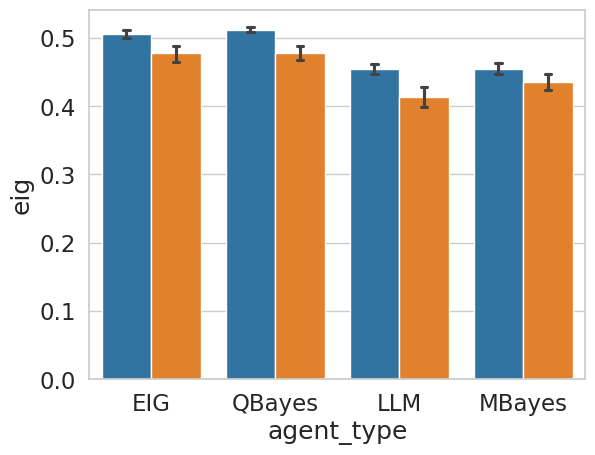

In [31]:
sns.barplot(
    data=filtered_df_cleaned, 
    hue='model_name', 
    y='eig', 
    x='agent_type', 
    capsize=0.1,
    legend=None,
)

In [32]:
# Calculate the average eig for each (model_name, agent_type) combination
average_eig = filtered_df_cleaned.groupby(['model_name', 'agent_type'])['eig'].mean().reset_index()
average_eig.rename(columns={'eig': 'average_eig'}, inplace=True)

average_eig

,model_name,agent_type,average_eig
0,meta-llama/llama-4-scout,EIG,0.477584
1,meta-llama/llama-4-scout,LLM,0.413254
2,meta-llama/llama-4-scout,MBayes,0.435657
3,meta-llama/llama-4-scout,QBayes,0.477391
4,openai/gpt-4o,EIG,0.505707
5,openai/gpt-4o,LLM,0.454791
6,openai/gpt-4o,MBayes,0.455092
7,openai/gpt-4o,QBayes,0.512169


In [33]:
eig_zero_count = filtered_df_cleaned[filtered_df_cleaned['eig'] == 0].groupby(['model_name', 'agent_type']).size().reset_index(name='eig_zero_count')
# Calculate the fraction of redundant questions
eig_zero_count['redundant_fraction'] = eig_zero_count['eig_zero_count'] / filtered_df_cleaned.groupby(['model_name', 'agent_type']).size().reset_index(name='total_questions')['total_questions']

eig_zero_count

,model_name,agent_type,eig_zero_count,redundant_fraction
0,meta-llama/llama-4-scout,LLM,3,0.006466
